# Mock Member Health Analysis - Feature Engineering

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os


## 2. Load Raw Dataset



In [2]:
df = pd.read_csv("../data/processed/member_eda_ready.csv")
df.head()

,member_id,age,gender,region,plan_type,chronic_condition_count,engagement_score,ed_visits,ip_admits,monthly_cost,awv_completed,engagement_group,age_group
0,M00001,69,Female,Rural,DSNP,3,72.6,1,1,2634.13,0,Q4,65-79
1,M00002,32,Female,Suburban,Medicare Advantage,0,71.5,0,1,1632.38,1,Q4,18-34
2,M00003,89,Male,Suburban,Medicaid,2,32.6,0,0,978.36,1,Q1,80+
3,M00004,78,Male,Suburban,Medicare Advantage,7,56.0,3,0,2761.83,1,Q3,65-79
4,M00005,38,Female,Urban,DSNP,2,42.2,0,1,2001.45,1,Q1,35-49


## 3. Quick Validation

In [3]:
df.shape

(500, 13)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   member_id                500 non-null    str    
 1   age                      500 non-null    int64  
 2   gender                   500 non-null    str    
 3   region                   500 non-null    str    
 4   plan_type                500 non-null    str    
 5   chronic_condition_count  500 non-null    int64  
 6   engagement_score         500 non-null    float64
 7   ed_visits                500 non-null    int64  
 8   ip_admits                500 non-null    int64  
 9   monthly_cost             500 non-null    float64
 10  awv_completed            500 non-null    int64  
 11  engagement_group         500 non-null    str    
 12  age_group                500 non-null    str    
dtypes: float64(2), int64(5), str(6)
memory usage: 50.9 KB


In [5]:
df.isnull().sum() # Check for missing values in each column to assess data quality

member_id                  0
age                        0
gender                     0
region                     0
plan_type                  0
chronic_condition_count    0
engagement_score           0
ed_visits                  0
ip_admits                  0
monthly_cost               0
awv_completed              0
engagement_group           0
age_group                  0
dtype: int64

In [6]:
df["member_id"].duplicated().sum() # Check for duplicate member IDs to ensure data integrity

np.int64(0)

## 4. Feature Engineering

In [7]:
df["age_group"] = pd.cut(df["age"], 
                        bins=[17, 34, 49, 64, 79, 100], 
                        labels=["18-34", "35-49", "50-64", "65-79", "80+"]) # Create age groups for better analysis and modeling



In [8]:
df["engagement_group"] = pd.qcut(df["engagement_score"], 
                                q=4, 
                                labels=["Q1", "Q2", "Q3", "Q4"]) # Create engagement groups based on quartiles for better analysis and modeling

In [9]:
cost_threshold = df['monthly_cost'].quantile(0.75) # Calculate the 75th percentile of cost to identify outliers
df['high_cost_member'] = df['monthly_cost'] >= cost_threshold # Create a binary feature to indicate high-cost members for better analysis and modeling

In [10]:
df['has_acute_utilization'] = (
                                (df["ed_visits"] > 0 ) | (df["ip_admits"] > 0)
).astype(int) # Create a binary feature to indicate members with acute care utilization for better analysis and modeling

In [11]:
df['chronic_burden_group'] = pd.cut(df['chronic_condition_count'],
                                        bins = [-1,1,3,8],
                                        labels = ['Low', 'Moderate', 'High']) # Create chronic burden groups based on the number of chronic conditions for better analysis and modeling

## 5. Validate New Features

In [12]:
df[[
    'age_group',
    'engagement_group',
    'high_cost_member',
    'has_acute_utilization',
    'chronic_burden_group'
]].head()

,age_group,engagement_group,high_cost_member,has_acute_utilization,chronic_burden_group
0,65-79,Q4,True,1,Moderate
1,18-34,Q4,False,1,Low
2,80+,Q1,False,0,Moderate
3,65-79,Q3,True,1,High
4,35-49,Q1,True,1,Moderate


In [13]:
df["age_group"].value_counts().sort_index() # Check the distribution of members across age groups to understand the demographic composition of the dataset


age_group
18-34    126
35-49     98
50-64     98
65-79    119
80+       59
Name: count, dtype: int64

In [14]:
df["engagement_score"].value_counts().sort_index()

engagement_score
5.0      2
5.5      1
7.6      1
9.5      1
10.2     1
        ..
92.6     1
94.9     1
98.4     1
98.7     1
100.0    3
Name: count, Length: 359, dtype: int64

In [15]:
df["high_cost_member"].value_counts()

high_cost_member
False    375
True     125
Name: count, dtype: int64

In [16]:
df["has_acute_utilization"].value_counts()

has_acute_utilization
1    298
0    202
Name: count, dtype: int64

In [17]:
df["chronic_burden_group"].value_counts().sort_index()

chronic_burden_group
Low         148
Moderate    236
High        116
Name: count, dtype: int64

## 6. Refined Grouped Analysis

In [18]:
df.groupby("age_group", observed=False)["monthly_cost"].mean() # Analyze average monthly cost by age group to identify cost patterns across different age demographics

age_group
18-34    1042.863889
35-49    1143.811429
50-64    1407.046939
65-79    1881.608319
80+      1922.915085
Name: monthly_cost, dtype: float64

In [19]:
df.groupby("chronic_burden_group", observed=False)["monthly_cost"].mean() # Analyze average monthly cost by chronic burden group to identify cost patterns across different levels of chronic conditions

chronic_burden_group
Low          879.417838
Moderate    1483.463686
High        2056.009310
Name: monthly_cost, dtype: float64

In [20]:
df.groupby("awv_completed")["has_acute_utilization"].mean() # Analyze the relationship between annual wellness visit completion and acute care utilization to identify potential preventive care benefits

awv_completed
0    0.611842
1    0.589080
Name: has_acute_utilization, dtype: float64

In [21]:
df.groupby("plan_type")["high_cost_member"].mean() # Analyze the relationship between plan type and high-cost member status to identify potential cost drivers


plan_type
DSNP                  0.415385
Medicaid              0.200000
Medicare Advantage    0.256410
Name: high_cost_member, dtype: float64

In [22]:
df.groupby("chronic_burden_group", observed=False)["high_cost_member"].mean() # Analyze the relationship between chronic burden group and high-cost member status to identify potential cost drivers related to chronic conditions

chronic_burden_group
Low         0.020270
Moderate    0.216102
High        0.612069
Name: high_cost_member, dtype: float64

## 7. Key Visualizations

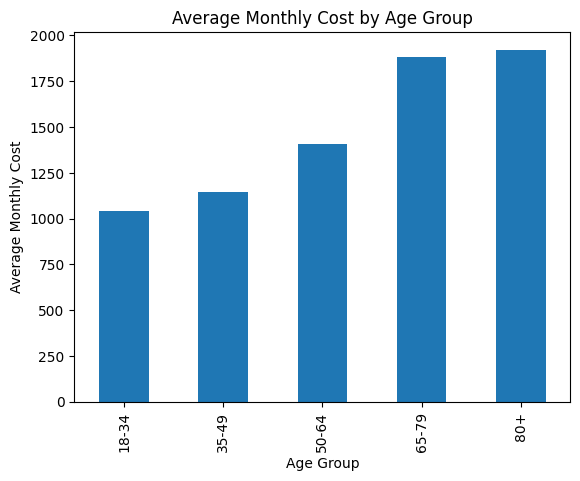

In [23]:
df.groupby("age_group", observed=False)["monthly_cost"].mean().plot(kind="bar") # Visualize average monthly cost by age group to identify cost patterns across different age demographics
plt.title("Average Monthly Cost by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Monthly Cost")
plt.show()

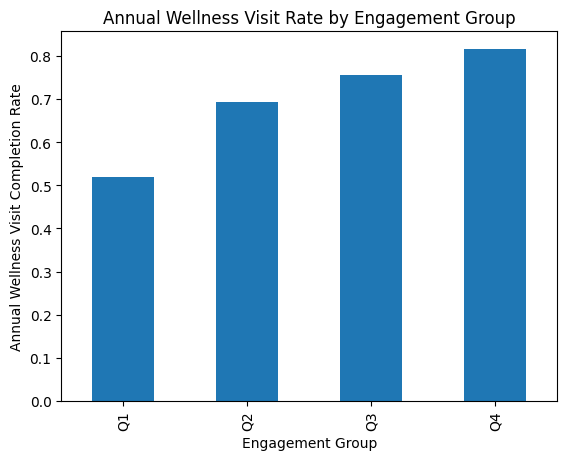

In [24]:
df.groupby("engagement_group", observed=False)["awv_completed"].mean().plot(kind="bar") # Visualize the relationship between engagement group and annual wellness visit completion to identify potential preventive care benefits across different engagement levels
plt.title("Annual Wellness Visit Rate by Engagement Group")
plt.xlabel("Engagement Group")
plt.ylabel("Annual Wellness Visit Completion Rate")
plt.show()


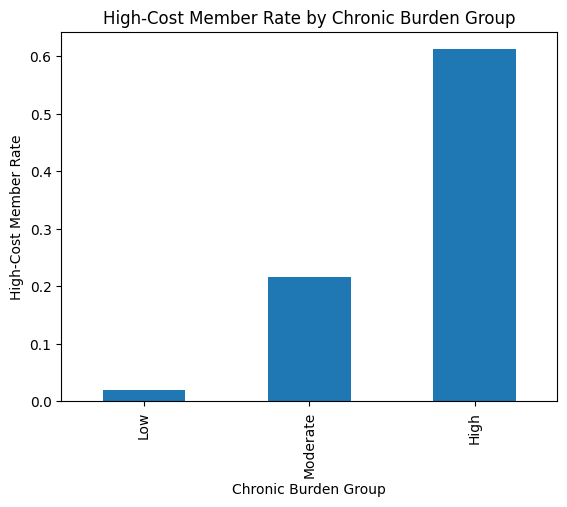

In [25]:
df.groupby("chronic_burden_group", observed=False)["high_cost_member"].mean().plot(kind="bar") # Analyze the relationship between chronic burden group and high-cost member status to identify potential cost drivers related to chronic conditions
plt.title("High-Cost Member Rate by Chronic Burden Group")
plt.xlabel("Chronic Burden Group")
plt.ylabel("High-Cost Member Rate")
plt.show()


## 8. Save Processed Dataset 

In [26]:
os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/member_analysis_ready.csv", index=False)

## 9. Refined Findings

1. Average monthly cost increases across older age groups.
2. Members in the high chronic burden group show higher average monthly cost and a higher share of high-cost members.
3. AWV completion tends to improve across higher engagement groups, although the relationship appears moderate rather than extreme.
4. Members with acute utilization may represent a more operationally important subgroup for further segmentation.
5. The dataset now includes engineered features that make it more suitable for downstream modeling and business-style analysis.